# Decision Tree Regression
Visualizing how trees approximate continuous functions using piecewise constant steps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from decision_tree_regressor import MyDecisionTreeRegressor

In [2]:
# Generate Sine Wave Data
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16)) # Add noise

## 1. Visualizing Fits at Different Depths
A shallow tree creates broad steps (underfitting). A deep tree captures every noise point (overfitting).

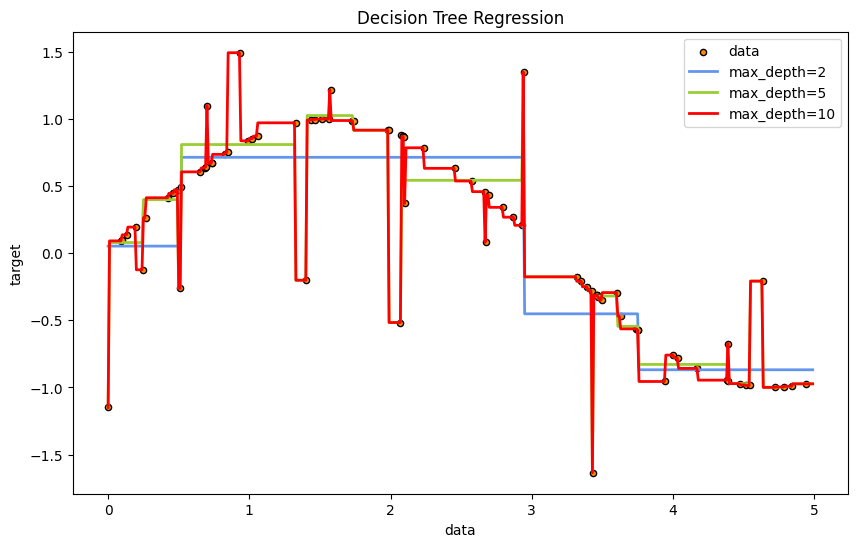

In [3]:
def plot_regression(depths):
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
    
    X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
    colors = ['cornflowerblue', 'yellowgreen', 'red']
    
    for depth, color in zip(depths, colors):
        regr = MyDecisionTreeRegressor(max_depth=depth)
        regr.fit(X, y)
        y_pred = regr.predict(X_test)
        plt.plot(X_test, y_pred, color=color, label=f"max_depth={depth}", linewidth=2)
        
    plt.xlabel("data")
    plt.ylabel("target")
    plt.title("Decision Tree Regression")
    plt.legend()
    plt.show()

plot_regression([2, 5, 10])